EDA 3: Hospital Segmentation Analysis

In [1]:
# Objective 
# To analyze how hospital performance varies across different segments such as state and hospital type.
# This helps identify structural and regional disparities in healthcare quality.

# Questions addressed through this EDA:
# 1- How does hospital performance vary accross different states?
# 2- Do certain hospital types (Public, Private, Non-Profit) perform better than others?
# 3- Is there significant variability with each hospital category?
# 4- Are performance patterns influenced more by geography or hospital type?

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))
from utils.feature_engineering import classify_measure, performance_direction


In [6]:
sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/cleaned_master_data.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4480288, 9)


,value,data_period,hospital_name,state,hospital_type,measure_code,measure_name,unit,reported_measure_name
0,108.00,2022-23,Byron Central Hospital,New South Wales,Local Hospital Network,Myh0006,Number Of Elective Surgeries,Surgeries,Urgent Elective Surgery
1,25.00,2022-23,Royal Rehabilitation Hospital,New South Wales,Local Hospital Network,Myh0006,Number Of Elective Surgeries,Surgeries,Laryngectomy
2,75.00,2022-23,Wingham Hospital,New South Wales,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Curettage And Evacuation Of Uterus
3,1620.00,2022-23,Launceston General Hospital,Tasmania,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Common Peroneal Nerve Release
4,85.16,2022-23,South West Healthcare [Camperdown],Victoria,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Procedure For Strabismus (Squint Repair)


Validating Required Columns


In [7]:
if 'measure_category' not in df.columns:
  df['measure_category']=df['measure_name'].apply(classify_measure)

if performance_direction not in df.columns:
  df['performance_direction']=df['measure_name'].apply(performance_direction)

df[['measure_name', 'measure_category', 'performance_direction']].drop_duplicates().head()

,measure_name,measure_category,performance_direction
0,Number Of Elective Surgeries,volume,neutral
2,Percentage Of Patients Who Waited Longer Than ...,percentage,higher_better
4,Median Waiting Time For Elective Surgery,time,lower_better
12,Number Of Patients Presenting To The Emergency...,volume,neutral
17,Number Of Hospital Stays,volume,neutral


Fetching Segmentation Columns

In [8]:
# We validate categorical columns to ensure they are clean and consistent for analysis.
# To detect missing values, imbalanced categories or too many states that may need filtering for better visualization.
# Dropping duplicates
print(df[['hospital_name', 'hospital_type', 'state']].drop_duplicates().head(10))
print("Unique hospital types:", df['hospital_type'].nunique())
print("Unique states:", df['state'].nunique())

                            hospital_name           hospital_type  \
0                  Byron Central Hospital  Local Hospital Network   
1           Royal Rehabilitation Hospital  Local Hospital Network   
2                        Wingham Hospital  Local Hospital Network   
3             Launceston General Hospital  Local Hospital Network   
4      South West Healthcare [Camperdown]  Local Hospital Network   
5                     Hervey Bay Hospital  Local Hospital Network   
6  Coolamon-Ganmain Multi Purpose Service  Local Hospital Network   
7               Wellington Health Service  Local Hospital Network   
8                      Caloundra Hospital  Local Hospital Network   
9                  Mullewa Health Service  Local Hospital Network   

               state  
0    New South Wales  
1    New South Wales  
2    New South Wales  
3           Tasmania  
4           Victoria  
5         Queensland  
6    New South Wales  
7    New South Wales  
8         Queensland  
9  Western

Checking Missing Values in Segmentation Columns

In [9]:
# Before grouping missinf categories can bias aggregation and cause skewness
# This is important for state-wise comparisons and hospital-type segmentation
missing_hospital_types = df['hospital_type'].isnull().sum()
print("Missing hospital types:", missing_hospital_types)
missing_states = df['state'].isnull().sum()
print("Missing states:", missing_states)

Missing hospital types: 0
Missing states: 0


Filtering Comparable Measures

In [12]:
df_pct=df[df['measure_category']=='percentage'].copy()
print("Percentage measures shape:", df_pct.shape)

Percentage measures shape: (1338131, 11)


Aggregate Performance per Hospital

In [16]:
hospital_perf = df_pct.groupby(
  ['hospital_name', 'hospital_type', 'state']
)['value'].mean().reset_index()

hospital_perf.rename(columns={'value': 'avg_performance'}, inplace=True)
hospital_perf.head()

,hospital_name,hospital_type,state,avg_performance
0,Adelaide,Local Hospital Network,South Australia,170.760716
1,Adolescent And Young Adult Hospice Manly,Local Hospital Network,New South Wales,181.350038
2,Albany Hospital,Local Hospital Network,Western Australia,234.588864
3,Albury Wodonga Health [Albury Campus],Local Hospital Network,New South Wales,246.574094
4,Albury Wodonga Health [Wodonga Campus],Local Hospital Network,Victoria,184.192380


State-wise Aggragation

In [17]:
state_perf = hospital_perf.groupby(['state'])['avg_performance'].mean().reset_index()
state_perf=state_perf.sort_values(by='avg_performance', ascending=False)
state_perf.head()

,state,avg_performance
5,Tasmania,217.403594
2,Northern Territory,215.882016
0,Australian Capital Territory,206.965013
1,New South Wales,202.157913
6,Victoria,201.180114


Top States Visualization

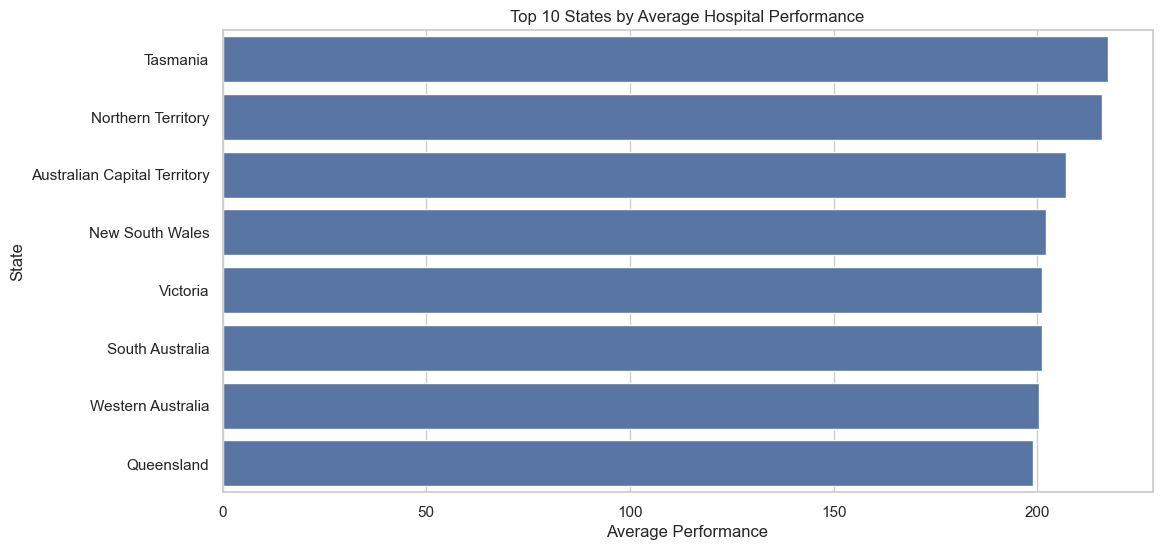

In [20]:
top_states = state_perf.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_states, x='avg_performance', y='state')
plt.title('Top 10 States by Average Hospital Performance')
plt.xlabel('Average Performance')
plt.ylabel('State')
plt.show()

Bottom States Visualization

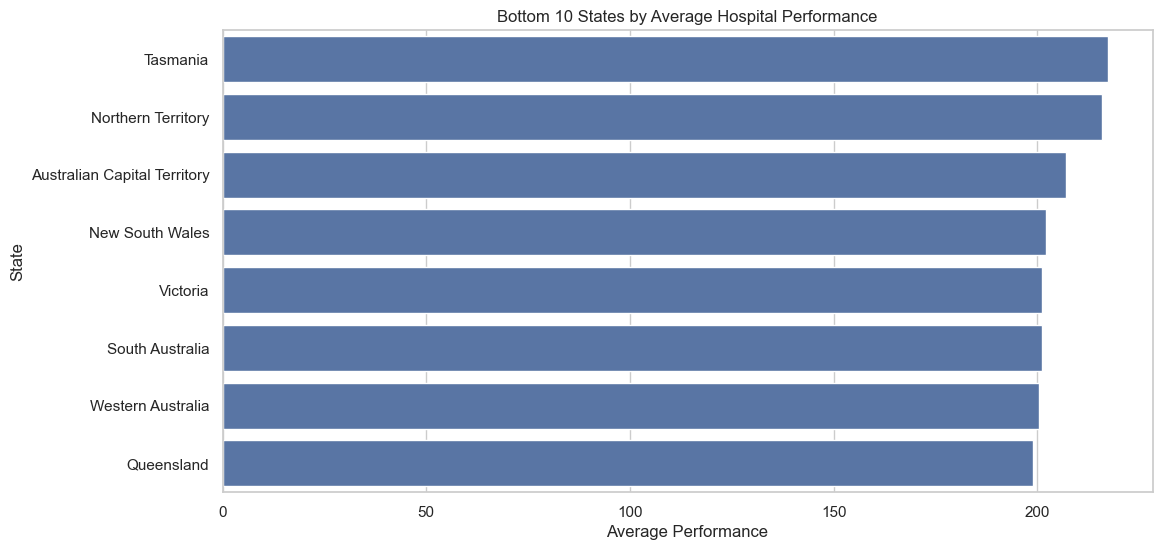

In [21]:
bottom_states = state_perf.tail(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=bottom_states, x='avg_performance', y='state')
plt.title('Bottom 10 States by Average Hospital Performance')
plt.xlabel('Average Performance')
plt.ylabel('State')
plt.show()